In [124]:
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import seaborn as sns

from matplotlib import colors
from copy import deepcopy


%matplotlib inline

In [125]:
from copy import deepcopy

from rashomon import hasse
from rashomon import loss
from rashomon import counter
from rashomon import metrics
from rashomon import extract_pools
from rashomon.aggregate import RAggregate_profile, RAggregate, find_profile_lower_bound, find_feasible_combinations, remove_unused_poolings
from rashomon.sets import RashomonSet, RashomonProblemCache, RashomonSubproblemCache

%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


# Read processed data

In [126]:
df = pd.read_csv("../Data/NHANES_telomere.csv")
df_std = pd.read_csv("../Data/NHANES_telomere_std.csv")

df.head()

,Telomean,HoursWorked,Gender,Age,Race,Education,MaritalStatus,HouseholdIncome
0,0.389337,>=41,Female,<=18,Hispanic,< GED,Single,20k-45k
1,0.389337,21-40,Female,31-50,Other,College,Married,20k-45k
2,0.433244,>=41,Male,>=70,White,GED,Married,<20k
3,0.433244,21-40,Male,31-50,White,College,Married,45k-75k
4,0.443293,>=41,Female,31-50,Other,College,Married,>=75k


{'whiskers': [<matplotlib.lines.Line2D at 0x3d032d310>,
 'caps': [<matplotlib.lines.Line2D at 0x3d032f8d0>,
 'boxes': [<matplotlib.lines.Line2D at 0x3d032dad0>,
 'medians': [<matplotlib.lines.Line2D at 0x3d032e750>,
 'fliers': [<matplotlib.lines.Line2D at 0x3d03397d0>,
 'means': []}

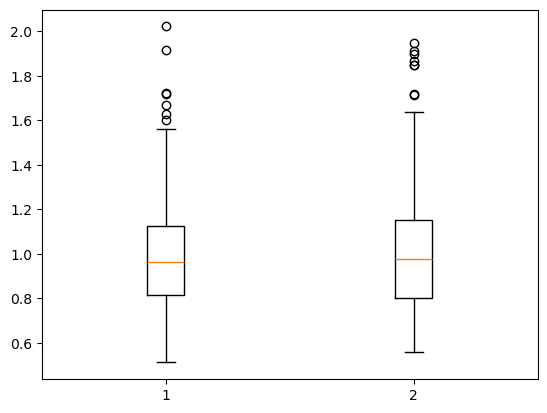

In [199]:
sub=df[df["Race"]==1]
plt.boxplot(x=[sub[sub["Age"]==1].Telomean,sub[sub["Age"]==2].Telomean])

In [127]:
hours_worked_map = {
    "<=20": 1,
    "21-40": 2,
    ">=41": 3
}

gender_map = {
    "Female": 1,
    "Male": 2
}

age_map = {
    "<=18": 1,
    "19-30": 2,
    "31-50": 3,
    "51-70": 4,
    ">=70": 5
}

race_map = {
    "White": 1,
    "Black": 2,
    "Hispanic": 3,
    "Other": 3
}

education_map = {
    "< GED": 1,
    "GED": 2,
    "College": 3
}

marital_status_map = {
    "Single": 1,
    "Married": 2,
    "Divorced/Widowed": 3
}

income_map = {
    "<20k": 1,
    "20k-45k": 2,
    "45k-75k": 3,
    ">=75k": 4
}


df["HoursWorked"] = df["HoursWorked"].map(hours_worked_map)
df["Gender"] = df["Gender"].map(gender_map)
df["Age"] = df["Age"].map(age_map)
df["Race"] = df["Race"].map(race_map)
df["Education"] = df["Education"].map(education_map)
df["MaritalStatus"] = df["MaritalStatus"].map(marital_status_map)
df["HouseholdIncome"] = df["HouseholdIncome"].map(income_map)



df_std["HoursWorked"] = df_std["HoursWorked"].map(hours_worked_map)
df_std["Gender"] = df_std["Gender"].map(gender_map)
df_std["Age"] = df_std["Age"].map(age_map)
df_std["Race"] = df_std["Race"].map(race_map)
df_std["Education"] = df_std["Education"].map(education_map)
df_std["MaritalStatus"] = df_std["MaritalStatus"].map(marital_status_map)
df_std["HouseholdIncome"] = df_std["HouseholdIncome"].map(income_map)


df2 = df.drop(df[df['Telomean'] > 9].index)
df_std_2 = df_std.drop(df_std[df_std['Telomean'] > 9].index)

df.head()

,Telomean,HoursWorked,Gender,Age,Race,Education,MaritalStatus,HouseholdIncome
0,0.389337,3,1,1,3,1,1,2
1,0.389337,2,1,3,3,3,2,2
2,0.433244,3,2,5,1,2,2,1
3,0.433244,2,2,3,1,3,2,3
4,0.443293,3,1,3,3,3,2,4


In [128]:
# np.random.seed(3)

# category = "Gender"

# fig, ax = plt.subplots(figsize=(5,5))

# ax.spines[['right', 'top', 'left', 'bottom']].set_visible(False)

# # x_ticks = np.sort(pd.unique(beta_df[category])) - 1
# # x_labels = categories_values[category]

# # # Draw vertical grid lines
# # vert_line_y = [np.min(beta_subset) *0.8, np.max(beta_subset) * 1.1]
# # for x_tick in x_ticks:
# #     vert_line_x = [x_tick, x_tick]
# #     ax.plot(vert_line_x, vert_line_y, color="black", linewidth=0.7)

# # # Draw horizontal grid lines
# # hor_line_x = [np.min(x_ticks)-0.3, np.max(x_ticks)+0.3]
# # hor_line_y_vals = [0.8, 1.0, 1.2, 1.4, 1.6]
# # for y_val in hor_line_y_vals:
# #     hor_line_y = [y_val, y_val]
# #     ax.plot(hor_line_x, hor_line_y, color="black", linewidth=0.7, ls="--")

# # The actual plot
# # ax = sns.violinplot(x=category, y="Telostd", data=df_std_2, color="gray", edgecolor="black", linewidth=0.7,
# #                   # size=5,
# #                     alpha=0.8,
# #                     # jitter=0.15,
# #                     dodge=True)#, saturation=1)
# ax = sns.violinplot(x=category, y="Telomean", data=df_std_2, color="gray", edgecolor="black", linewidth=0.7,
#                   # size=5,
#                     alpha=0.8,
#                     # jitter=0.15,
#                     dodge=True)#, saturation=1)


# ax.set_ylabel("Average effects in the Rashomon set")
# ax.set_xlabel(category)
# ax.set_title("")
# # ax.set_xticks(x_ticks, x_labels)
# yticks = [0.006, 0.008, 0.010, 0.012, 0.014, 0.016]
# yticks_labels = ["$" + str(round(x * 100, 2)) for x in yticks]
# # ax.set_yticks(yticks, yticks_labels)


# # plt.savefig("../Figures/price_charity/conditional_effects.png", dpi=300, bbox_inches="tight")
# # plt.savefig("../Figures/price_charity/rset_size_dist_poster.pdf", dpi=600, bbox_inches="tight")
# plt.show()

In [129]:
Z = df.to_numpy()

# Delete the outlier
Z = np.delete(Z, [4877], axis=0)

X = Z[:, [1, 2, 3, 5]]
y = Z[:, 0]
# y = (y - np.min(y)) / (np.max(y) - np.min(y))
y = y.reshape((-1, 1))

num_data = X.shape[0]
print(f"There are {num_data} data points")

There are 4877 data points


# Analysis

In [130]:
M = 4
R = np.array([4, 3, 6, 4])

num_profiles = 2**M
profiles, profile_map = hasse.enumerate_profiles(M)

all_policies = hasse.enumerate_policies(M, R)
num_policies = len(all_policies)

policies_profiles = {}
policies_profiles_masked = {}
policies_ids_profiles = {}
for k, profile in enumerate(profiles):

    policies_temp = [(i, x) for i, x in enumerate(all_policies) if hasse.policy_to_profile(x) == profile]
    unzipped_temp = list(zip(*policies_temp))
    policies_ids_k = list(unzipped_temp[0])
    policies_k = list(unzipped_temp[1])
    policies_profiles[k] = deepcopy(policies_k)
    policies_ids_profiles[k] = policies_ids_k

    profile_mask = list(map(bool, profile))

    # Mask the empty arms
    for idx, pol in enumerate(policies_k):
        policies_k[idx] = tuple([pol[i] for i in range(M) if profile_mask[i]])
    policies_profiles_masked[k] = policies_k

In [131]:
D = np.zeros(shape=y.shape, dtype=np.int64)
profiles_in_data = []
for i in range(num_data):
    policy_i = tuple([int(x) for x in X[i, :]])
    policy_idx = [idx for idx in range(num_policies) if all_policies[idx] == policy_i]
    profiles_in_data.append(hasse.policy_to_profile(policy_i))
    D[i, 0] = int(policy_idx[0])


# policy_means = loss.compute_policy_means(D, y, num_policies)



# true_best_eff = np.max(mu_policies)
# print(true_best_eff)
# np.where(mu_policies == true_best_eff)

In [132]:
race_profiles = np.unique(Z[:, 4])

all_active_profile = tuple([1] * M)

policies_temp = [(i, x) for i, x in enumerate(all_policies) if hasse.policy_to_profile(x) == all_active_profile]
unzipped_temp = list(zip(*policies_temp))
policy_race_idx = list(unzipped_temp[0])
policy_race = list(unzipped_temp[1])

D_race = {}
X_race = {}
y_race = {}
policy_means_race = {}
mu_policies_race = {}
true_best_eff_race = {}
policy_means = np.zeros(shape=(len(policy_race), 2))
for race in race_profiles:
    idx = np.where(Z[:, 4] == race)
    X_race[race] = X[idx, :][0]
    y_race[race] = y[idx, :][0]
    num_data_race = X_race[race].shape[0]
    
    D_race[race] = np.zeros(shape=y_race[race].shape, dtype=np.int64)
    for i in range(num_data_race):
        policy_i = tuple([int(x) for x in X_race[race][i, :]])
        policy_idx = [idx for idx in range(num_policies) if all_policies[idx] == policy_i]
        D_race[race][i, 0] = int(policy_idx[0])
    
    range_list = list(np.arange(len(policy_race_idx)))
    policy_map = {i: x for i, x in zip(policy_race_idx, range_list)}
    D_race[race] = np.vectorize(policy_map.get)(D_race[race])


    policy_means_race[race] = loss.compute_policy_means(D_race[race], y_race[race], len(policy_race))
    
    nodata_idx = np.where(policy_means_race[race][:, 1] == 0)[0]
    policy_means_race[race][nodata_idx, 0] = -np.inf
    policy_means_race[race][nodata_idx, 1] = 1
    mu_policies_race[race] = policy_means_race[race][:, 0] / policy_means_race[race][:, 1]
    policy_means_race[race][nodata_idx, 1] = 0

    policy_means_race[race][nodata_idx, 0] = 0
    policy_means += policy_means_race[race]
    policy_means_race[race][nodata_idx, 0] = -np.inf

    true_best_eff_race[race] = np.max(mu_policies_race[race])
    # print(true_best_eff, np.where(mu_policies_race[race] == true_best_eff_race[race]))

nodata_idx = np.where(policy_means[:, 1] == 0)[0]
policy_means[nodata_idx, 0] = -np.inf
policy_means[nodata_idx, 1] = 1
mu_policies = policy_means[:, 0] / policy_means[:, 1]
policy_means[nodata_idx, 1] = 0

true_best_eff = np.max(mu_policies)
# print(true_best_eff, np.where(mu_policies == true_best_eff))

In [133]:
D_remapped = D.copy()
range_list = list(np.arange(len(policy_race_idx)))
policy_map = {i: x for i, x in zip(policy_race_idx, range_list)}
D_remapped = np.vectorize(policy_map.get)(D_remapped)

In [134]:
policy_race_idx_full = {}
for k, race in enumerate(race_profiles):
    policy_race_idx_full[k] = (k*len(range_list) + np.array(range_list)).tolist()

In [135]:
policy_means_race_full = np.concatenate((policy_means_race[1], policy_means_race[2], policy_means_race[3]), axis=0)

## Enumerate the Rashomon set

In [136]:
# H = 100
H = np.inf

# # This is too restrictive
# reg = 1e-2

# With reg = 1e-5, theta = 0.09, H = 60
# Best loss = 0.06423696912419681, Worst loss = 0.06535629544158826, epsilon = 0.01742495532794093

reg = 1e-5
# theta = 0.09

best_loss = 0.06423696912419681
# eps = 0.01
eps = 0.004
theta = best_loss * (1 + eps)
print(theta)

0.0644939170006936


In [137]:
# In the best case, every other profile becomes a single pool
# So max number of pools per profile is adjusted accordingly
# H_profile = H - num_profiles + 1
unordered_factors = race_profiles
num_unordered_factors = len(unordered_factors)
H_profile = H - num_unordered_factors + 1

# Subset data by profiles and find equiv policy lower bound
D_profiles = {}
y_profiles = {}
policies_profiles = {}
policy_means_profiles = {}
eq_lb_profiles = np.zeros(shape=(num_unordered_factors,))
for k, profile in enumerate(unordered_factors):

    policy_profiles_idx_k = policy_race_idx
    policies_profiles[k] = policy_race

    D_k = D_race[profile]
    # range_list = list(np.arange(len(policy_profiles_idx_k)))
    # policy_map = {i: x for i, x in zip(policy_profiles_idx_k, range_list)}
    # D_k = np.vectorize(policy_map.get)(D_k)
    y_k = y_race[profile]
    D_profiles[k] = D_k
    y_profiles[k] = y_k

    if D_k is None:
        policy_means_profiles[k] = None
        eq_lb_profiles[k] = 0
        H_profile += 1
    else:
        policy_means_k = policy_means_race[profile]
        policy_means_profiles[k] = policy_means_k
        eq_lb_profiles[k] = find_profile_lower_bound(D_k, y_k, policy_means_k)

eq_lb_profiles /= num_data
eq_lb_sum = np.sum(eq_lb_profiles)
print(eq_lb_profiles, eq_lb_sum)

# # Now solve each profile independently
# # This step can be parallelized
rashomon_profiles: list[RashomonSet] = [None]*num_unordered_factors
feasible = True
for k, profile in enumerate(unordered_factors):
    theta_k = theta - (eq_lb_sum - eq_lb_profiles[k])
    print(theta_k)
    D_k = D_profiles[k]
    y_k = y_profiles[k]

    policies_k = policies_profiles[k]
    policy_means_k = policy_means_profiles[k]
    profile_mask = list(map(bool, all_active_profile))
    # print(profile_mask)

    # # Mask the empty arms
    for idx, pol in enumerate(policies_k):
        policies_k[idx] = tuple([pol[i] for i in range(M) if profile_mask[i]])
    # R_k = R[profile_mask]
    # M_k = np.sum(profile)
    R_k = R
    M_k = M
    # print(len(policies_k), policy_means_k.shape)

    if D_k is None:
        # TODO: Put all possible sigma matrices here and set loss to 0
        rashomon_profiles[k] = RashomonSet(shape=None)
        rashomon_profiles[k].P_qe = [None]
        rashomon_profiles[k].Q = np.array([0])
        continue

    # Control group is just one policy
    if M_k == 0:
        rashomon_k = RashomonSet(shape=None)
        control_loss = eq_lb_profiles[k] + reg
        rashomon_k.P_qe = [None]
        rashomon_k.Q = np.array([control_loss])
    else:
        rashomon_k = RAggregate_profile(M_k, R_k, H_profile, D_k, y_k, theta_k, all_active_profile, reg,
                                        policies_k, policy_means_k, normalize=num_data)
        rashomon_k.calculate_loss(D_k, y_k, policies_k, policy_means_k, reg, normalize=num_data)

    rashomon_k.sort()
    rashomon_profiles[k] = rashomon_k
    if len(rashomon_k) == 0:
        feasible = False
        print(f"No Rashomon set for race profile {profile}")
        break
    else:
        print(f"Race: {profile}. Found {len(rashomon_profiles[k])} partitions")
        

# Combine solutions in a feasible way
if feasible:
    R_set = find_feasible_combinations(rashomon_profiles, theta, H, sorted=True)
else:
    R_set = []
if len(R_set) > 0:
    rashomon_profiles = remove_unused_poolings(R_set, rashomon_profiles)

print(len(R_set))

[0.02779666 0.01150502 0.02279098] 0.062092659166321756
0.030197915989282592
Race: 1.0. Found 512 partitions
0.013906274893460517
Race: 2.0. Found 512 partitions
0.025192241786694172
Race: 3.0. Found 512 partitions
390281


In [138]:
# for k, profile in enumerate(race_profiles):
#     print(f"Race: {profile}. Found {len(rashomon_profiles[k])} partitions")

In [139]:
rashomon_homogeneous = RAggregate_profile(M, R, H, D_remapped, y, theta, all_active_profile, reg,
                                          policy_race, policy_means, normalize=num_data)
rashomon_homogeneous.calculate_loss(D_remapped, y, policy_race, policy_means, reg, normalize=num_data)

print(len(rashomon_homogeneous))

0


In [140]:
R_set_pruned = []

for r in R_set:
    current_sigma = None
    # homoegeneous = False
    homoegeneous = True
    for race in race_profiles:
        race = int(race) - 1
        sigma_id = r[race]
        sigma_race = rashomon_profiles[race].sigma[sigma_id]
        if current_sigma is None:
            current_sigma = sigma_race
        elif not np.array_equal(current_sigma, sigma_race):
            homoegeneous = False
            break
    
    if homoegeneous:
        found_in_homogeneous = False
        for idx, r_sigma in enumerate(rashomon_homogeneous.sigma):
            if np.array_equal(r_sigma, current_sigma):
                found_in_homogeneous = True
                R_set_pruned.append([-1, idx])
                break
        if not found_in_homogeneous:
            print("Not found :(")
        else:
            R_set_pruned.append(r)
    else:
        R_set_pruned.append(r)

print(len(R_set_pruned))

Not found :(
Not found :(
Not found :(
Not found :(
390277


## Pickling
Save and load the pickle file for the Rashomon set with parameters
\begin{align*}
H &= 100 \\
\lambda &= 10^{-4} \\
\epsilon &= 0.01 \text{ or } \epsilon = 0.004\\
\theta &= 0.06487933881543878
\end{align*}

In [19]:
# import pickle

# full_rashomon_data = {
#   "R_set_pruned": R_set_pruned,
#    "rashomon_profiles": rashomon_profiles,
#    "rashomon_homogeneous": rashomon_homogeneous
# } 

# with open("../Results/nhanes_r_set_outlier_small_eps.pkl", "wb") as f:
#    pickle.dump(full_rashomon_data, f, pickle.HIGHEST_PROTOCOL)

# print("Done pickling!")

In [20]:
# import pickle


# # pickle_fname = "../Results/harvard_talk_april_11_pickles/NHANES/nhanes_r_set_outlier_small_eps.pkl"
# pickle_fname = "../Results/nhanes_r_set_outlier_small_eps.pkl"

# with open(pickle_fname, "rb") as f:
#     full_rashomon_data = pickle.load(f)

# R_set_pruned = full_rashomon_data["R_set_pruned"]
# rashomon_profiles = full_rashomon_data["rashomon_profiles"]
# rashomon_homogeneous = full_rashomon_data["rashomon_homogeneous"]

## Do analysis on the Rashomon set

In [21]:
model_losses = []
model_sizes = []

for i, r in enumerate(R_set_pruned):
    if r[0] == -1:
        model_i = r[1]
        loss_i = rashomon_homogeneous.loss[model_i]
        size_i = rashomon_homogeneous.pools[model_i]
    else:
        model_i = r
        loss_i = 0
        size_i = 0
        for race, race_model in enumerate(model_i):
            loss_i += rashomon_profiles[race].loss[race_model]
            size_i += rashomon_profiles[race].pools[race_model]
    model_losses.append(loss_i)
    model_sizes.append(size_i)

model_losses = np.array(model_losses)
model_sizes = np.array(model_sizes)
# model_mses = model_losses - reg * model_sizes

best_loss = np.min(model_losses)
worst_loss = np.max(model_losses)

eps = (worst_loss - best_loss) / best_loss
print(f"Best loss = {best_loss}, Worst loss = {worst_loss}, epsilon = {eps}")

Best loss = 0.06415039215250255, Worst loss = 0.06449391696460308, epsilon = 0.005354991615388315


In [22]:
model_post_prob = np.exp(-model_losses)

rel_post_prob_ratio = (model_post_prob - np.max(model_post_prob)) / np.max(model_post_prob)


In [ ]:
scaled_prob_threshold = 0.6
model_size_threshold = 80

q0 = best_loss
strict_eps = 0.0005
loss_threshold = q0 * (1 + strict_eps)

precomputed_pools = {}

R_set_2 = []
model_sizes_2 = []
model_losses_2 = []
model_pools_2 = []
model_pool_means_2 = []
for idx, r_set in enumerate(R_set_pruned):
    
    if model_losses[idx] > loss_threshold:
        continue

    if r_set[0] != -1:
        pi_policies_profiles_r = {}
        for race, model_race in enumerate(r_set):
            sigma_r_prof = rashomon_profiles[race].sigma[model_race]
            sigma_bytes = sigma_r_prof.tobytes()
            if sigma_bytes in precomputed_pools.keys():
                _, pi_policies_r_k = precomputed_pools[sigma_bytes]
            else:
                pi_pools_r_k, pi_policies_r_k = extract_pools.extract_pools(policy_race, sigma_r_prof)
                precomputed_pools[sigma_bytes] = (pi_pools_r_k, pi_policies_r_k)
            pi_policies_profiles_r[race] = pi_policies_r_k
    
        pi_pools_r, pi_policies_r = extract_pools.aggregate_pools(pi_policies_profiles_r, policy_race_idx_full)
        pool_means_r = loss.compute_pool_means(policy_means_race_full, pi_pools_r)

    else:
        sigma_r = rashomon_homogeneous.sigma[r_set[1]]
        sigma_bytes = sigma_r.tobytes()
        if sigma_bytes in precomputed_pools.keys():
            pi_pools_r, pi_policies_r = precomputed_pools[sigma_bytes]
        else:
            pi_pools_r, pi_policies_r = extract_pools.extract_pools(policy_race, sigma_r)
            precomputed_pools[sigma_bytes] = (pi_pools_r, pi_policies_r)
        # pi_pools_r, pi_policies_r = extract_pools.extract_pools(policy_race, sigma_r)
        pool_means_r = loss.compute_pool_means(policy_means, pi_pools_r)
        # TODO: Check whether the policy ids are correctly mapped
        # If not, map them here instead of when estimating effects


    R_set_2.append(r_set)
    model_sizes_2.append(model_sizes[idx])
    model_losses_2.append(model_losses[idx])
    model_pools_2.append(pi_pools_r)
    model_pool_means_2.append(pool_means_r)

print(len(R_set_2))


model_sizes_2 = np.array(model_sizes_2)
model_losses_2 = np.array(model_losses_2)
model_mses_2 = model_losses_2 - reg * model_sizes_2
model_post_prob_2 = np.exp(-model_losses_2)
model_scaled_post_prob_2 = model_post_prob_2 - np.min(model_post_prob_2)
model_scaled_post_prob_2 = model_scaled_post_prob_2 / np.max(model_scaled_post_prob_2)


best_loss = np.min(model_losses_2)
worst_loss = np.max(model_losses_2)

eps = (worst_loss - best_loss) / best_loss
print(f"Best loss = {best_loss}, Worst loss = {worst_loss}, epsilon = {eps}")

13
Best loss = 0.06415039215250255, Worst loss = 0.06417872543427283, epsilon = 0.00044166965812030283


In [24]:
rashomon_reduced_data = {
    "R_set": R_set_2,
    "sizes": model_sizes_2,
    "losses": model_losses_2,
    "pools": model_pools_2,
    "pool_means": model_pool_means_2
}

with open("../Results/nhanes_pruned_results_outlier.pkl", "wb") as f:
    pickle.dump(rashomon_reduced_data, f, pickle.HIGHEST_PROTOCOL)

In [25]:
# pruned_pickle_fname = "../Results/harvard_talk_april_11_pickles/NHANES/nhanes_pruned_results_outlier.pkl"
pruned_pickle_fname = "../Results/nhanes_pruned_results_outlier.pkl"

with open(pruned_pickle_fname, "rb") as f:
    rashomon_reduced_data = pickle.load(f)

R_set_2 = rashomon_reduced_data["R_set"]
model_sizes_2 = rashomon_reduced_data["sizes"]
model_losses_2 = rashomon_reduced_data["losses"]
model_pools_2 = rashomon_reduced_data["pools"]
model_pool_means_2 = rashomon_reduced_data["pool_means"]


# model_mses_2 = model_losses_2 - reg * model_sizes_2
model_post_prob_2 = np.exp(-model_losses_2)
model_scaled_post_prob_2 = model_post_prob_2 - np.min(model_post_prob_2)
model_scaled_post_prob_2 = model_scaled_post_prob_2 / np.max(model_scaled_post_prob_2)


best_loss = np.min(model_losses_2)
worst_loss = np.max(model_losses_2)

eps = (worst_loss - best_loss) / best_loss
print(f"Best loss = {best_loss}, Worst loss = {worst_loss}, epsilon = {eps}")

Best loss = 0.06415039215250255, Worst loss = 0.06417872543427283, epsilon = 0.00044166965812030283


In [26]:
rel_post_prob_ratio_2 = (model_post_prob_2 - np.max(model_post_prob)) / np.max(model_post_prob)
min_rel_post_prob_2 = np.min(rel_post_prob_ratio_2)

print(min_rel_post_prob_2)

-2.8332880386598658e-05


# larger RPS

In [166]:
scaled_prob_threshold = 0.6
model_size_threshold = 80

q0 = best_loss
strict_eps = 0.0007
loss_threshold = q0 * (1 + strict_eps)

precomputed_pools = {}

R_set_3 = []
model_sizes_3 = []
model_losses_3 = []
model_pools_3 = []
model_pool_means_3 = []
for idx, r_set in enumerate(R_set_pruned):
    
    if model_losses[idx] > loss_threshold:
        continue

    if r_set[0] != -1:
        pi_policies_profiles_r = {}
        for race, model_race in enumerate(r_set):
            sigma_r_prof = rashomon_profiles[race].sigma[model_race]
            sigma_bytes = sigma_r_prof.tobytes()
            if sigma_bytes in precomputed_pools.keys():
                _, pi_policies_r_k = precomputed_pools[sigma_bytes]
            else:
                pi_pools_r_k, pi_policies_r_k = extract_pools.extract_pools(policy_race, sigma_r_prof)
                precomputed_pools[sigma_bytes] = (pi_pools_r_k, pi_policies_r_k)
            pi_policies_profiles_r[race] = pi_policies_r_k
    
        pi_pools_r, pi_policies_r = extract_pools.aggregate_pools(pi_policies_profiles_r, policy_race_idx_full)
        pool_means_r = loss.compute_pool_means(policy_means_race_full, pi_pools_r)

    else:
        sigma_r = rashomon_homogeneous.sigma[r_set[1]]
        sigma_bytes = sigma_r.tobytes()
        if sigma_bytes in precomputed_pools.keys():
            pi_pools_r, pi_policies_r = precomputed_pools[sigma_bytes]
        else:
            pi_pools_r, pi_policies_r = extract_pools.extract_pools(policy_race, sigma_r)
            precomputed_pools[sigma_bytes] = (pi_pools_r, pi_policies_r)
        # pi_pools_r, pi_policies_r = extract_pools.extract_pools(policy_race, sigma_r)
        pool_means_r = loss.compute_pool_means(policy_means, pi_pools_r)
        # TODO: Check whether the policy ids are correctly mapped
        # If not, map them here instead of when estimating effects


    R_set_3.append(r_set)
    model_sizes_3.append(model_sizes[idx])
    model_losses_3.append(model_losses[idx])
    model_pools_3.append(pi_pools_r)
    model_pool_means_3.append(pool_means_r)

print(len(R_set_3))


model_sizes_3 = np.array(model_sizes_3)
model_losses_3 = np.array(model_losses_3)
model_mses_3 = model_losses_3 - reg * model_sizes_3
model_post_prob_3 = np.exp(-model_losses_3)
model_scaled_post_prob_3 = model_post_prob_3 - np.min(model_post_prob_3)
model_scaled_post_prob_3 = model_scaled_post_prob_3 / np.max(model_scaled_post_prob_3)


best_loss = np.min(model_losses_3)
worst_loss = np.max(model_losses_3)

eps = (worst_loss - best_loss) / best_loss
print(f"Best loss = {best_loss}, Worst loss = {worst_loss}, epsilon = {eps}")

42
Best loss = 0.06415039215250255, Worst loss = 0.06419524269529116, epsilon = 0.0006991468217681835


In [161]:
beta_models3 = []

for i, model in enumerate(R_set_3):

    beta_i = np.zeros(270)
    pool_means_i = model_pool_means_3[i]

    # Get the beta vector
    for pool_id in range(len(pool_means_i)):
        for policy in model_pools_3[i][pool_id]:
            beta_i[policy] = pool_means_i[pool_id]

    beta_models3.append(beta_i)

## AIS Sampling from NHANES RPS

In [27]:
from rashomon import AIS, MCMC

In [28]:
n_per_race = len(policy_race)  # 90 policies per race

# Global policy IDs: race 0 (White) → [0,89], race 1 (Black) → [90,179], race 2 (Other) → [180,269]
D_nhanes = np.zeros(shape=(num_data, 1), dtype=np.int64)
for i in range(num_data):
    race_i = int(Z[i, 4]) - 1  # race 1,2,3 → 0-indexed
    D_nhanes[i, 0] = race_i * n_per_race + int(D_remapped[i, 0])

policies_nhanes = policy_race + policy_race + policy_race  # 270 policies (90 per race)
prof_idx_of_policy_nhanes = np.array([0]*n_per_race + [1]*n_per_race + [2]*n_per_race)
policy_means_nhanes = policy_means_race_full  # shape (270, 2)
print(f'D_nhanes shape: {D_nhanes.shape}, policies: {len(policies_nhanes)}')

D_nhanes shape: (4877, 1), policies: 270


In [29]:
RPS_states = []
for r_set in R_set_2:
    state = []
    for race_idx in range(3):
        if r_set[0] == -1:
            sigma = rashomon_homogeneous.sigma[r_set[1]]
        else:
            sigma = rashomon_profiles[race_idx].sigma[r_set[race_idx]]
        B = AIS._as_compact_B(sigma)
        state.append(AIS.ProfilePart(cov_ids=all_active_profile, B=B))
    RPS_states.append(state)

print(f'Built {len(RPS_states)} RPS states from R_set_2')

Built 13 RPS states from R_set_2


In [30]:
def score_s_nhanes(state):
    total_loss = 0.0
    for race_idx, race in enumerate([1, 2, 3]):
        pp = state[race_idx]
        sigma_full = AIS.assemble_sigma_full_for_profile(pp, M, R)
        D_k = D_race[race]
        y_k = y_race[race]
        pm_k = loss.compute_policy_means(D_k, y_k, n_per_race)
        if sigma_full is None:
            y_flat = np.asarray(y_k).ravel()
            mu_k = float(np.mean(y_flat)) if y_flat.size else 0.0
            mse_k = float(np.mean((y_flat - mu_k) ** 2)) * y_flat.size / num_data if y_flat.size else 0.0
            Q_k = mse_k + reg
        else:
            Q_k = float(loss.compute_Q(D_k, y_k, sigma_full, policy_race, pm_k, reg=reg, normalize=num_data))
        total_loss += Q_k
    return float(np.exp(-total_loss))

In [201]:
log_alpha = list(-model_losses_2)

eps1 = 0.5
eps2 = 0.75
# ladder = [0, 0.05, 0.15, 0.35, 0.55, 0.75, 0.875, 1]
cfg = AIS.AISConfig(n_paths=500, n_levels=20, moves_per_level=5, min_len=1, seed=2)

buckets = AIS.make_p0_buckets_weighted_S0(
    RPS_states, np.asarray(R, int), log_alpha,
    eps1=eps1, eps2=eps2, min_len=1
)
print(f'Buckets: S0={len(buckets.S0_sigs)}, S1={buckets.size_S1}, S>1={buckets.size_Sgt1}')

Buckets: S0=13, S1=206, S>1=134217509


In [73]:
from functools import partial
log_p0 = partial(AIS.log_p0_distance_weighted_S0_wrapper, buckets=buckets)
init_sampler = partial(
    AIS.init_from_RPS_batch_wrapper,
    RPS_states=RPS_states,
    log_alpha=log_alpha,
    rng_seed=777,
)

ladder, ess_ratios = AIS.pilot_adaptive_ladder(
        init_sampler=init_sampler,
        log_p0=log_p0,
        score_s=score_s_nhanes,
        N=512,
        ess_target=0.80,
        beta0=0.0, beta1=1.0,
        initial_delta=0.05,
        min_delta=1e-3,
        moves_per_probe=3,   # small mixing at each accepted β (optional)
        min_len=1,
        rng_seed=777
    )

In [202]:
ais_out = AIS.run_ais_state_streaming(
    buckets=buckets,
    anchors=RPS_states,
    score_s=score_s_nhanes,
    cfg=cfg,
    RPS=RPS_states,
    R_per=np.asarray(R, int),
    eps1=eps1,
    eps2=eps2,
    out_jsonl='./AIS_nhanes_samples500.jsonl',
    ladder=ladder,
)
print(f'AIS complete: {len(ais_out.terminals)} terminals')

AIS complete: 500 terminals


In [ ]:
ais_mu_hat = AIS.estimate_policy_means_from_ais(
    ais_out=ais_out,
    all_policies=policies_nhanes,
    policy_means=policy_means_nhanes,
    R_per=R,
    M=M,
    prof_idx_of_policy=prof_idx_of_policy_nhanes,
    lattice_edges=None,
)
print('AIS posterior mean shape:', ais_mu_hat.shape)

In [ ]:
ais_summ = AIS.ais_quantiles_for_all_policies_root(
    ais_out,
    D_nhanes, y,
    M,
    policies_nhanes,
    prof_idx_of_policy_nhanes,
    R,
    lattice_edges=None,
    mu0=0.0, kappa0=1.0, alpha0=2.0, beta0=2.0,
    p=[0.025, 0.5, 0.975],
    seed=None
)
print('AIS quantile keys:', list(ais_summ.keys()))

### Estimating effects

In [35]:
all_policies_race = []
for race in race_profiles:
    for pol in policy_race:
        pol = tuple([x for x in pol] + [int(race)])
        all_policies_race.append(pol)

In [ ]:
policies_present = np.sort(np.unique(D_remapped))

beta = np.zeros(270)


for i, model in enumerate(R_set_2):

    beta_i = np.zeros(270)
    pool_means_i = model_pool_means_2[i]

    # Do some calculation
    for pool_id in range(len(pool_means_i)):
        for policy in model_pools_2[i][pool_id]:
            if model[0] == -1:
                beta_i[policy] = pool_means_i[pool_id]
                beta_i[policy+90] = pool_means_i[pool_id]
                beta_i[policy+180] = pool_means_i[pool_id]
                pass
            else:
                beta_i[policy] = pool_means_i[pool_id]

    beta += beta_i * model_post_prob_2[i]

beta /= np.sum(model_post_prob_2)

beta_subset = beta

beta_subset_sorted = list(np.sort(beta_subset))

policy_id_1 = np.where(beta == beta_subset_sorted[-1])[0][0]
policy_id_2 = np.where(beta == beta_subset_sorted[-2])[0][0]
policy_id_3 = np.where(beta == beta_subset_sorted[-3])[0][0]
policy_id_4 = np.where(beta == beta_subset_sorted[-4])[0][0]
policy_id_worst = np.where(beta == beta_subset_sorted[0])[0][0]

print(f"Best \t\t {all_policies_race[policy_id_1]} \t{beta_subset_sorted[-1]}")
print(f"Second Best \t {all_policies_race[policy_id_2]} \t{beta_subset_sorted[-2]}")
print(f"Third Best \t {all_policies_race[policy_id_3]} \t{beta_subset_sorted[-3]}")
print(f"Fourth Best \t {all_policies_race[policy_id_4]} \t{beta_subset_sorted[-4]}")
print(f"Worst \t\t {all_policies_race[policy_id_worst]} \t{beta_subset_sorted[0]}")

Best 		 (np.int64(2), np.int64(2), np.int64(5), np.int64(3), 3) 	1.8856543072199998
Second Best 	 (np.int64(1), np.int64(2), np.int64(5), np.int64(3), 3) 	1.7958615494871168
Third Best 	 (np.int64(2), np.int64(2), np.int64(5), np.int64(2), 3) 	1.7509652559147724
Fourth Best 	 (np.int64(1), np.int64(2), np.int64(5), np.int64(2), 3) 	1.6611724981818894
Worst 		 (np.int64(1), np.int64(1), np.int64(5), np.int64(1), 1) 	0.5749015359398053


In [ ]:
beta_df = []
for idx, policy in enumerate(all_policies_race):
    beta_df.append([beta_subset[idx]] + list(policy))

beta_df = pd.DataFrame(beta_df, columns=["Tel", "Work", "Gender", "Age", "Education", "Race"])

categories_values = {
    "Work": [r"$\leq 20$ hrs", r"$21 - 40$ hrs", r"$\geq 40$ hrs"],
    "Gender": ["Female", "Male"],
    "Age": [r"$\leq 18$", r"$19 - 30$", r"$31 - 50$", r"$51 - 70$", r"$\geq 71$"],
    "Education": ["< GED", "GED", "College"],
    "Race": ["White", "Black", "Other"]
}

## Plots for effects

## Inspecting models

The arms are:
- HoursWorked - 3 levels
- Gender - female, male
- Age - 5 levels
- Education - 3 levels

Race was 3 levels - white, black, other

In [46]:
splits_white = np.zeros(rashomon_profiles[0].sigma[0].shape)
splits_black = np.zeros(splits_white.shape)
splits_other = np.zeros(splits_white.shape)
splits_overall = np.zeros(splits_white.shape)
overall_ctr = 0

for r_set in R_set_2:
    if r_set[0] == -1:
        idx = r_set[1]
        splits_overall += np.abs(rashomon_homogeneous.sigma[idx] - 1)
        splits_white += np.abs(rashomon_homogeneous.sigma[idx] - 1)
        splits_black += np.abs(rashomon_homogeneous.sigma[idx] - 1)
        splits_other += np.abs(rashomon_homogeneous.sigma[idx] - 1)
        overall_ctr += 1
    else:
        idx_white = r_set[0]
        idx_black = r_set[1]
        idx_other = r_set[2]
    
        splits_white += np.abs(rashomon_profiles[0].sigma[idx_white] - 1)
        splits_black += np.abs(rashomon_profiles[1].sigma[idx_black] - 1)
        splits_other += np.abs(rashomon_profiles[2].sigma[idx_other] - 1)

splits_white = splits_white / len(R_set_2) # * 100
splits_black = splits_black / len(R_set_2) # * 100
splits_other = splits_other / len(R_set_2) # * 100
if overall_ctr > 0:
    splits_overall = splits_overall / overall_ctr # * 100

In [47]:
print("White\n", splits_white)
print("Black\n", splits_black)
print("Other\n", splits_other)
print("Overall\n", splits_overall)

White
 [[1.         1.                inf        inf]
 [1.                inf        inf        inf]
 [1.         1.         1.         0.46153846]
 [1.         0.                inf        inf]]
Black
 [[0.15384615 1.                inf        inf]
 [1.                inf        inf        inf]
 [0.15384615 0.23076923 0.84615385 0.15384615]
 [0.30769231 0.84615385        inf        inf]]
Other
 [[0.         1.                inf        inf]
 [0.15384615        inf        inf        inf]
 [1.         1.         0.15384615 1.        ]
 [1.         0.                inf        inf]]
Overall
 [[0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]]


In [48]:
best_model_idx = np.argmin(model_losses_2)
worst_model_idx = np.argmax(model_losses_2)

In [49]:
idx = worst_model_idx

num_pools = 0
for k, prof in enumerate(R_set_2[idx]):
    print(rashomon_profiles[k].sigma[prof])
    num_pools += rashomon_profiles[k].pools[prof]
print(f"There are {num_pools} pools.")
best_pool_idx = np.argmax(model_pool_means_2[idx])
print(model_pool_means_2[idx][best_pool_idx])
print([all_policies_race[x] for x in model_pools_2[idx][best_pool_idx]])


worst_pool_idx = np.argmin(model_pool_means_2[idx])
print(model_pool_means_2[idx][worst_pool_idx])
print([all_policies_race[x] for x in model_pools_2[idx][worst_pool_idx]])

[[ 0.  0. inf inf]
 [ 0. inf inf inf]
 [ 0.  0.  0.  0.]
 [ 0.  1. inf inf]]
[[ 1.  0. inf inf]
 [ 0. inf inf inf]
 [ 1.  1.  0.  0.]
 [ 1.  0. inf inf]]
[[ 1.  0. inf inf]
 [ 1. inf inf inf]
 [ 0.  0.  1.  0.]
 [ 0.  1. inf inf]]
There are 100.0 pools.
1.88565430722
[(np.int64(1), np.int64(1), np.int64(5), np.int64(2), 3), (np.int64(2), np.int64(1), np.int64(5), np.int64(2), 3), (np.int64(2), np.int64(2), np.int64(5), np.int64(2), 3), (np.int64(2), np.int64(2), np.int64(5), np.int64(3), 3), (np.int64(1), np.int64(2), np.int64(5), np.int64(3), 3), (np.int64(2), np.int64(1), np.int64(5), np.int64(3), 3), (np.int64(1), np.int64(2), np.int64(5), np.int64(2), 3), (np.int64(1), np.int64(1), np.int64(5), np.int64(3), 3)]
0.0
[(np.int64(1), np.int64(1), np.int64(5), np.int64(1), 1)]


### Heatmap-esque plots

In [50]:
med_tel = np.median(y)
print(med_tel)

3.0


In [51]:
all_policies_race_reverse = {}
for x, y in enumerate(all_policies_race):
    all_policies_race_reverse[y] = x

In [52]:
beta_models = []

for i, model in enumerate(R_set_2):

    beta_i = np.zeros(270)
    pool_means_i = model_pool_means_2[i]

    # Get the beta vector
    for pool_id in range(len(pool_means_i)):
        for policy in model_pools_2[i][pool_id]:
            beta_i[policy] = pool_means_i[pool_id]

    beta_models.append(beta_i)

In [53]:
all_covariate_counts = []
all_model_prob_counts = []

# normalized_model_post_prob_2 = model_post_prob_2 / np.sum(model_post_prob_2)

for covariate_idx in range(4):

    num_cov_values = R[covariate_idx]
    
    counts_per_race = [[] for i in range(num_cov_values - 2)]
    model_prob_per_race = [[] for i in range(num_cov_values - 2)]
    
    # covariate_counts = [{1: [], 2: [], 3: []}] * 2
    covariate_counts = [deepcopy(counts_per_race) for i in range(3)]
    model_probs_counts = [deepcopy(model_prob_per_race) for i in range(3)]
    
    for i, beta_i in enumerate(beta_models): # For each model in the rashomon set
        #2435 models so 2435 betas
        for policy_id, policy in enumerate(all_policies_race): # For each policy
            
            if policy[covariate_idx] == 1: # lowest level
                continue
                
            control = list(deepcopy(policy))
            control[covariate_idx] = 1
            control_id = all_policies_race_reverse[tuple(control)]
    
            eff = beta_i[policy_id] - beta_i[control_id] # This is the
    
            race = policy[4] # race idx
            covariate_val = policy[covariate_idx] # covariate level rank, will -2 to represent rank without the lowest level
            
            covariate_counts[race - 1][covariate_val - 2].append(eff)
            model_probs_counts[race - 1][covariate_val - 2].append(model_post_prob_2[i])

    all_covariate_counts.append(covariate_counts)
    all_model_prob_counts.append(model_probs_counts)

In [ ]:
len(all_policies_race)

270

In [54]:
stds = np.zeros((4, 3))
for covariate_idx in range(4):
    for race_idx in range(3):
        stds[covariate_idx, race_idx] = np.std(all_covariate_counts[covariate_idx][race_idx])

In [55]:
signed_matrices = []
num_bins = 5

def assign_label(a, bins):
    if a == 0:
        return (len(bins) - 1) // 2
    else:
        return np.digitize(a, bins) - (a > 0)
    
assign_label_vec = np.vectorize(assign_label)

for covariate_idx in range(len(all_covariate_counts)):
    signed_counts = []
    for race_idx in range(len(all_covariate_counts[covariate_idx])):
        covariate_counts = all_covariate_counts[covariate_idx]
        # print(f"Covariate: {covariate_idx}, Race: {race_idx}")
        stddev = stds[covariate_idx, race_idx]
        all_eff = np.array(covariate_counts[race_idx]).flatten()
        if num_bins != 3:
            bins = [min(np.min(all_eff), stddev * -(3)) - 1] + [2 * stddev * i for i in np.arange(-1, 2, 3/(num_bins - 2))] + [max(np.max(all_eff), stddev * 3) + 1]
        else:
            bins = [min(np.min(all_eff), stddev * -(3)) - 1] + [0] + [max(np.max(all_eff), stddev * 3) + 1]
        bins = bins[::-1]
        signed_counts_race = []
        # print(len(covariate_counts[race_idx]))
        for idx, cov_counts_r in enumerate(covariate_counts[race_idx]):
            vec = np.array(cov_counts_r)
            counts_vec = np.array([assign_label(vec[i], bins) for i in range(len(vec))])
            counts_vec = np.array([np.dot(np.where(counts_vec == i, 1, 0), all_model_prob_counts[covariate_idx][race_idx][idx]) for i in range(len(bins))])
            counts_vec /= np.sum(counts_vec)
            signed_counts_race.append(counts_vec.copy())
        signed_counts.append(signed_counts_race)
    signed_matrices.append(np.array(signed_counts))

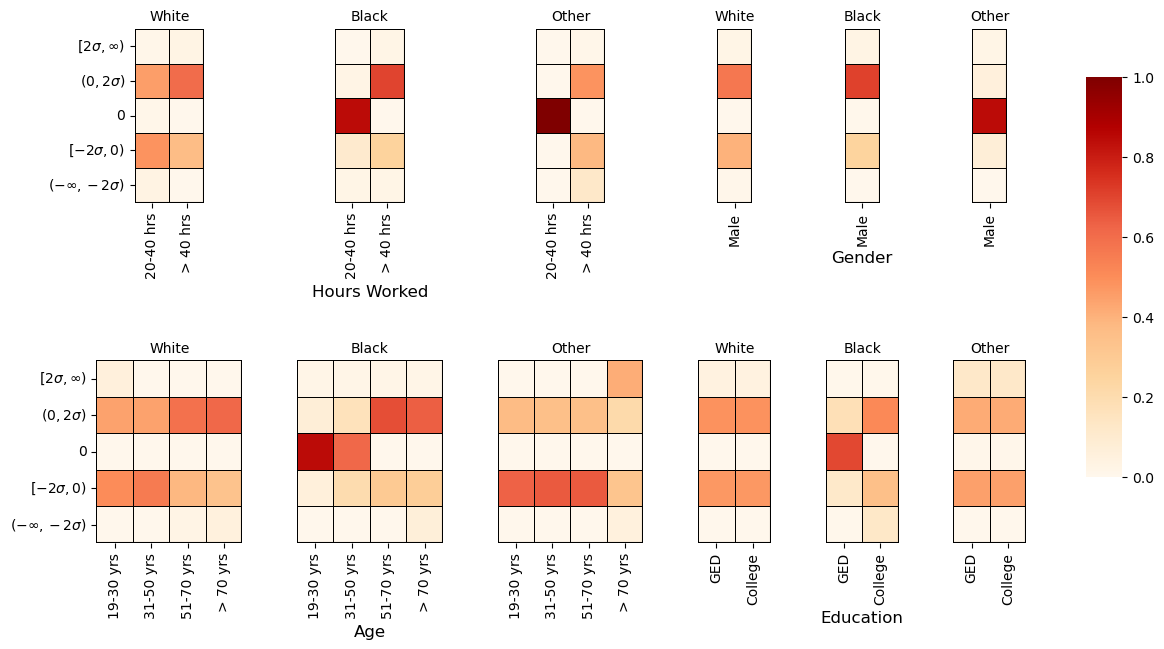

In [ ]:
reorder = [0, 1, 2, 3]

cov_labels = ["Hours Worked", "Gender", "Age", "Education"]

levels_labels = [
    ["20-40 hrs", "> 40 hrs"],
    ["Male"],
    ["19-30 yrs", "31-50 yrs", "51-70 yrs", "> 70 yrs"],
    ["GED", "College"]
]

covariate_idx = 2
plot_matrix = signed_matrices[covariate_idx]

race_title = ["White", "Black", "Other"]

num_cov_vals = R[covariate_idx] - 2

fig = plt.figure(figsize=(12, 8)) #layout=None, facecolor='lightblue')
gs = fig.add_gridspec(nrows=1*2, ncols=3*2, #, left=0.05, right=0.75,
                      # hspace=0.3,
                      wspace=0.5,
                      width_ratios=[1, 1, 1, 0.5, 0.5, 0.5],
                      height_ratios=[0.45, 1]
                     )

cbar_ax = fig.add_axes([.95, .32, .03, .5])

if num_bins == 3:
    bin_labels = ["+", "0", "-"]
else:
    interval_length = 4 // (num_bins - 3)
    num_signed_levels = (2 // interval_length) - 1
    bin_labels = [r"$[2\sigma, \infty)$"]
    for i in range(num_signed_levels):
        label_i_str = rf"$[{2 - (i + 1) * interval_length}\sigma, {2 - i * interval_length}\sigma)$"
        bin_labels.append(label_i_str)
    bin_labels += [rf"$(0, {interval_length}\sigma)$", "0", rf"$[-{interval_length}\sigma, 0)$"]
    for i in range(num_signed_levels):
        label_i_str = rf"$[{-(2 + i) * interval_length}\sigma, {-(1 + i) * interval_length}\sigma)$"
        bin_labels.append(label_i_str)
    bin_labels.append(r"$(-\infty, -2\sigma)$")
        


for covariate_idx in range(4):

    i = covariate_idx // 2
    covariate_idx = reorder[covariate_idx]
    
    plot_matrix = signed_matrices[covariate_idx]
    num_cov_vals = R[covariate_idx] - 2
    
    for idx in range(3):
        # i = 0
        j = idx + (covariate_idx % 2) *3
    
        # print(plot_matrix[i][j])
    
        ax_ij = fig.add_subplot(gs[i, j])
        res = sns.heatmap(
            plot_matrix[idx].T,
            cmap="OrRd",
            linewidths=0.5,
            linecolor="black",
            square=True,
            vmin=0,
            vmax=1,
            ax=ax_ij,
            cbar_ax=cbar_ax
        )
        res.axhline(y=len(bins), color='black', linewidth=1.5)
        res.axvline(x=len(all_covariate_counts[covariate_idx][idx]), color='black', linewidth=1.5)
        ax_ij.set_title(race_title[idx], fontsize=10, rotation=0)
        ax_ij.set_yticks([])
        ax_ij.set_xticks(np.arange(0, num_cov_vals)+0.5, levels_labels[covariate_idx], rotation=90)
        if j == 0:
            ax_ij.set_yticks(np.arange(0, num_bins) + 0.5, bin_labels, rotation=0)
        # break

        if idx == 1:
            ax_ij.set_xlabel(cov_labels[covariate_idx], fontsize=12)
    # fig.supxlabel(cov_labels[covariate_idx])

fname = f"../Figures/nhanes_new/diff_covariate_effects_{num_bins}_bins_13.png"
    
plt.savefig(fname, dpi=300, bbox_inches="tight")

plt.show()

### AIS Effects

In [203]:
_r = AIS.load_ais_from_jsonl('./AIS_nhanes_samples500.jsonl'); ais_out = AIS.AISOutput(terminals=_r['terminals'], logw=_r['logw'], normw=(lambda w: w/w.sum())(np.exp(_r['logw']-np.max(_r['logw']))), ladder=None)

In [204]:
# For each AIS terminal state, extract per-race pool assignments and compute beta
beta_models_ais = []

for state in ais_out.terminals:
    beta_i = np.zeros(270)
    for race_idx, race in enumerate(race_profiles):  # race_profiles = [1,2,3]
        pp = state[race_idx]
        sigma_full = AIS.assemble_sigma_full_for_profile(pp, M, R)
        pi_pools_k, pi_policies_k = extract_pools.extract_pools(policy_race, sigma_full)
        pool_means_k = loss.compute_pool_means(policy_means_race[race], pi_pools_k)
        for local_idx in range(n_per_race):
            pool_id = pi_policies_k[local_idx]
            beta_i[race_idx * n_per_race + local_idx] = pool_means_k[pool_id]
    beta_models_ais.append(beta_i)

print(f'{len(beta_models_ais)} beta vectors built from AIS terminals')

500 beta vectors built from AIS terminals


In [205]:
all_policies_race = []
for race in race_profiles:
    for pol in policy_race:
        pol = tuple([x for x in pol] + [int(race)])
        all_policies_race.append(pol)

In [206]:
all_policies_race_reverse = {}
for x, y in enumerate(all_policies_race):
    all_policies_race_reverse[y] = x

In [207]:
all_covariate_counts_ais = []
all_model_prob_counts_ais = []

for covariate_idx in range(4):
    num_cov_values = R[covariate_idx]
    counts_per_race = [[] for _ in range(num_cov_values - 2)]
    model_prob_per_race = [[] for _ in range(num_cov_values - 2)]
    covariate_counts = [deepcopy(counts_per_race) for _ in range(3)]
    model_probs_counts = [deepcopy(model_prob_per_race) for _ in range(3)]

    for i, beta_i in enumerate(beta_models_ais):
        w_i = float(ais_out.normw[i])  # normalized AIS weight
        for policy_id, policy in enumerate(all_policies_race):
            if policy[covariate_idx] == 1:
                continue
            control = list(deepcopy(policy))
            control[covariate_idx] = 1
            control_id = all_policies_race_reverse[tuple(control)]
            eff = beta_i[policy_id] - beta_i[control_id]
            race = policy[4]
            covariate_val = policy[covariate_idx]
            covariate_counts[race - 1][covariate_val - 2].append(eff)
            model_probs_counts[race - 1][covariate_val - 2].append(w_i)

    all_covariate_counts_ais.append(covariate_counts)
    all_model_prob_counts_ais.append(model_probs_counts)

In [210]:
stds_ais = np.zeros((4, 3))
for covariate_idx in range(4):
    for race_idx in range(3):
        stds_ais[covariate_idx, race_idx] = np.std(all_covariate_counts_ais[covariate_idx][race_idx])

In [214]:
signed_matrices_ais = []
num_bins = 5

def assign_label(a, bins):
    if a == 0:
        return (len(bins) - 1) // 2
    else:
        return np.digitize(a, bins) - (a > 0)
    
assign_label_vec = np.vectorize(assign_label)

for covariate_idx in range(len(all_covariate_counts_ais)):
    signed_counts_ais = []
    for race_idx in range(len(all_covariate_counts_ais[covariate_idx])):
        covariate_counts = all_covariate_counts_ais[covariate_idx]
        # print(f"Covariate: {covariate_idx}, Race: {race_idx}")
        stddev = stds_ais[covariate_idx, race_idx]
        all_eff = np.array(covariate_counts[race_idx]).flatten()
        if num_bins != 3:
            bins = [min(np.min(all_eff), stddev * -(3)) - 1] + [2 * stddev * i for i in np.arange(-1, 2, 3/(num_bins - 2))] + [max(np.max(all_eff), stddev * 3) + 1]
        else:
            bins = [min(np.min(all_eff), stddev * -(3)) - 1] + [0] + [max(np.max(all_eff), stddev * 3) + 1]
        bins = bins[::-1]
        signed_counts_race = []
        # print(len(covariate_counts[race_idx]))
        for idx, cov_counts_r in enumerate(covariate_counts[race_idx]):
            vec = np.array(cov_counts_r)
            counts_vec = np.array([assign_label(vec[i], bins) for i in range(len(vec))])
            counts_vec = np.array([np.dot(np.where(counts_vec == i, 1, 0), all_model_prob_counts_ais[covariate_idx][race_idx][idx]) for i in range(len(bins))])
            counts_vec /= np.sum(counts_vec)
            signed_counts_race.append(counts_vec.copy())
        signed_counts_ais.append(signed_counts_race)
    signed_matrices_ais.append(np.array(signed_counts_ais))

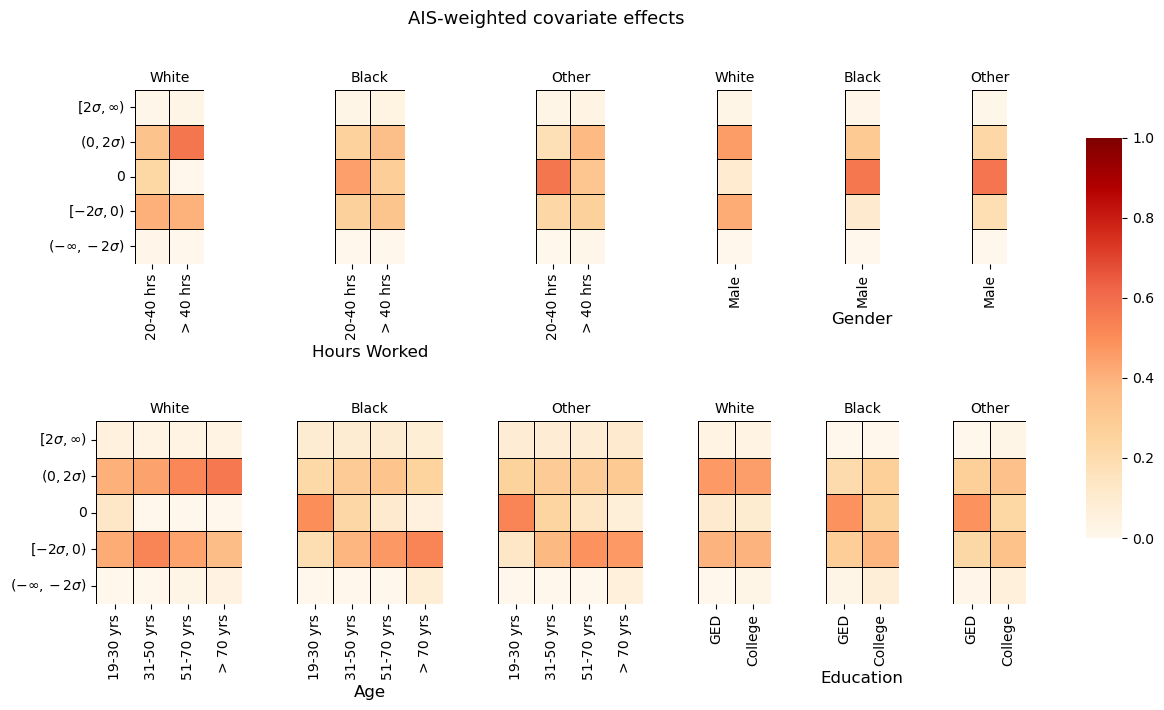

In [215]:
reorder = [0, 1, 2, 3]
race_title = ["White", "Black", "Other"]
cov_labels = ["Hours Worked", "Gender", "Age", "Education"]

levels_labels = [
    ["20-40 hrs", "> 40 hrs"],
    ["Male"],
    ["19-30 yrs", "31-50 yrs", "51-70 yrs", "> 70 yrs"],
    ["GED", "College"]
]

fig = plt.figure(figsize=(12, 8))
gs = fig.add_gridspec(nrows=2, ncols=6,
                      wspace=0.5,
                      width_ratios=[1, 1, 1, 0.5, 0.5, 0.5],
                      height_ratios=[0.45, 1])
cbar_ax = fig.add_axes([.95, .32, .03, .5])

if num_bins == 3:
    bin_labels = ["+", "0", "-"]
else:
    interval_length = 4 // (num_bins - 3)
    num_signed_levels = (2 // interval_length) - 1
    bin_labels = [r"$[2\sigma, \infty)$"]
    for bi in range(num_signed_levels):
        bin_labels.append(rf"$[{2-(bi+1)*interval_length}\sigma, {2-bi*interval_length}\sigma)$")
    bin_labels += [rf"$(0, {interval_length}\sigma)$", "0", rf"$[-{interval_length}\sigma, 0)$"]
    for bi in range(num_signed_levels):
        bin_labels.append(rf"$[{-(2+bi)*interval_length}\sigma, {-(1+bi)*interval_length}\sigma)$")
    bin_labels.append(r"$(-\infty, -2\sigma)$")

for covariate_idx in range(4):
    row = covariate_idx // 2
    cov = reorder[covariate_idx]
    plot_matrix = signed_matrices_ais[cov]
    num_cov_vals = R[cov] - 2
    for idx in range(3):
        col = idx + (cov % 2) * 3
        ax_ij = fig.add_subplot(gs[row, col])
        res = sns.heatmap(
            plot_matrix[idx].T,
            cmap="OrRd", linewidths=0.5, linecolor="black",
            square=True, vmin=0, vmax=1,
            ax=ax_ij, cbar_ax=cbar_ax
        )
        ax_ij.set_title(race_title[idx], fontsize=10)
        ax_ij.set_yticks([])
        ax_ij.set_xticks(np.arange(0, num_cov_vals) + 0.5, levels_labels[cov], rotation=90)
        if col == 0:
            ax_ij.set_yticks(np.arange(0, num_bins) + 0.5, bin_labels, rotation=0)
        if idx == 1:
            ax_ij.set_xlabel(cov_labels[cov], fontsize=12)

fig.suptitle('AIS-weighted covariate effects', fontsize=13)
plt.savefig(f'../Figures/nhanes_new/ais500_covariate_effects_{num_bins}_bins.png', dpi=300, bbox_inches='tight')
plt.show()

In [83]:
signed_matrices_diff = []
for i in range(len(signed_matrices)):
    signed_matrices_diff.append(signed_matrices_ais[i] - signed_matrices[i])

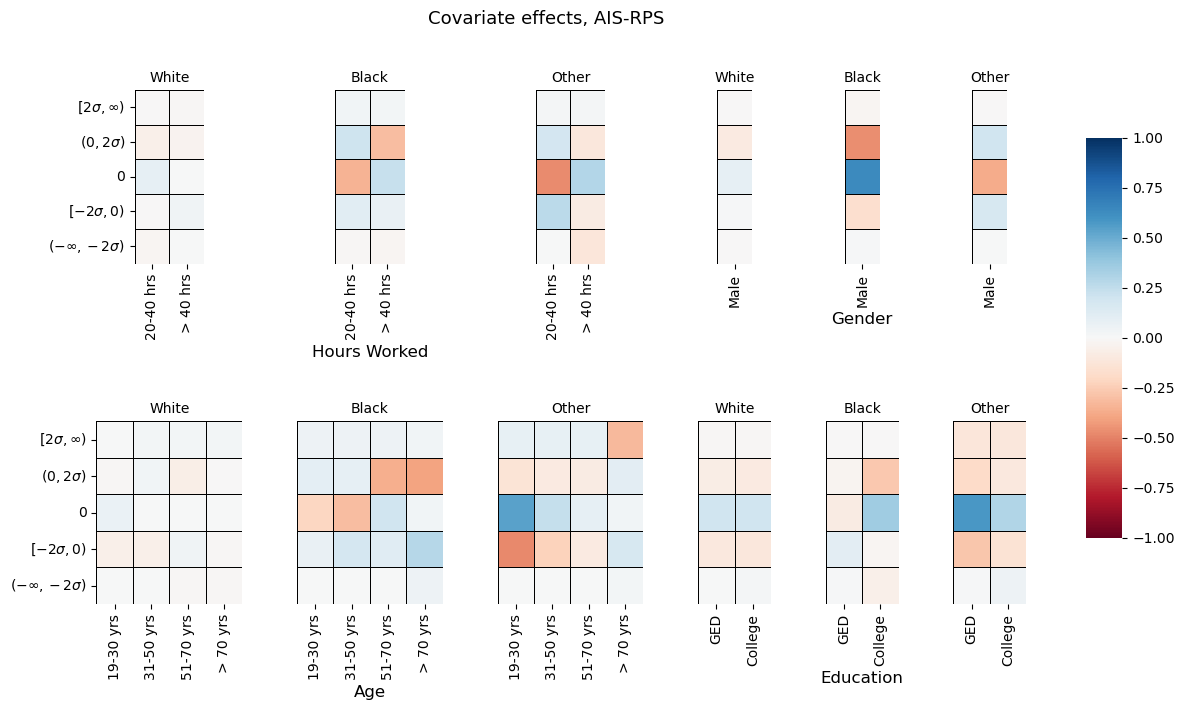

In [84]:
reorder = [0, 1, 2, 3]
race_title = ["White", "Black", "Other"]
cov_labels = ["Hours Worked", "Gender", "Age", "Education"]

levels_labels = [
    ["20-40 hrs", "> 40 hrs"],
    ["Male"],
    ["19-30 yrs", "31-50 yrs", "51-70 yrs", "> 70 yrs"],
    ["GED", "College"]
]

fig = plt.figure(figsize=(12, 8))
gs = fig.add_gridspec(nrows=2, ncols=6,
                      wspace=0.5,
                      width_ratios=[1, 1, 1, 0.5, 0.5, 0.5],
                      height_ratios=[0.45, 1])
cbar_ax = fig.add_axes([.95, .32, .03, .5])

if num_bins == 3:
    bin_labels = ["+", "0", "-"]
else:
    interval_length = 4 // (num_bins - 3)
    num_signed_levels = (2 // interval_length) - 1
    bin_labels = [r"$[2\sigma, \infty)$"]
    for bi in range(num_signed_levels):
        bin_labels.append(rf"$[{2-(bi+1)*interval_length}\sigma, {2-bi*interval_length}\sigma)$")
    bin_labels += [rf"$(0, {interval_length}\sigma)$", "0", rf"$[-{interval_length}\sigma, 0)$"]
    for bi in range(num_signed_levels):
        bin_labels.append(rf"$[{-(2+bi)*interval_length}\sigma, {-(1+bi)*interval_length}\sigma)$")
    bin_labels.append(r"$(-\infty, -2\sigma)$")

for covariate_idx in range(4):
    row = covariate_idx // 2
    cov = reorder[covariate_idx]
    plot_matrix = signed_matrices_diff[cov]
    num_cov_vals = R[cov] - 2
    for idx in range(3):
        col = idx + (cov % 2) * 3
        ax_ij = fig.add_subplot(gs[row, col])
        res = sns.heatmap(
            plot_matrix[idx].T,
            cmap="RdBu", linewidths=0.5, linecolor="black",
            square=True, vmin=-1, vmax=1,
            ax=ax_ij, cbar_ax=cbar_ax
        )
        ax_ij.set_title(race_title[idx], fontsize=10)
        ax_ij.set_yticks([])
        ax_ij.set_xticks(np.arange(0, num_cov_vals) + 0.5, levels_labels[cov], rotation=90)
        if col == 0:
            ax_ij.set_yticks(np.arange(0, num_bins) + 0.5, bin_labels, rotation=0)
        if idx == 1:
            ax_ij.set_xlabel(cov_labels[cov], fontsize=12)

fig.suptitle('Covariate effects, AIS-RPS', fontsize=13)
plt.savefig(f'../Figures/nhanes_new/300_diff_covariate_effects_{num_bins}_bins.png', dpi=300, bbox_inches='tight')
plt.show()

## Graphics for Explaining Heatmaps in Presentation

Hours Worked


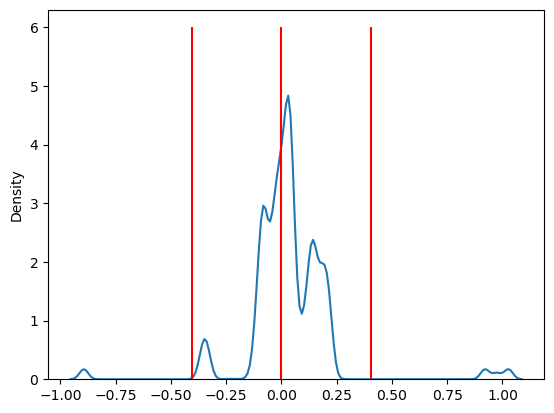

In [103]:
# Profile to consider is White 20-40 Hours

graphic_cov_idx, graphic_race_idx, group_idx = 1, 0, 0

print(cov_labels[0])
plot_effects = all_covariate_counts[graphic_cov_idx][graphic_race_idx][group_idx]

graphic_std = stds[graphic_cov_idx, graphic_race_idx]

sns.kdeplot(data=all_covariate_counts[graphic_cov_idx][graphic_race_idx][group_idx])
plt.vlines([-2 * graphic_std, 0 * graphic_std, 2 * graphic_std], ymin = 0, ymax=6, colors='r')
plt.show()

In [102]:
print(np.sum([1 if plot_effects[i] >= 0 and plot_effects[i] < 2 * graphic_std else 0 for i in range(len(plot_effects))]))

61458


In [91]:
len(df[(df['Race'] == 1) & (df['HoursWorked'] == 2)])

473

## Credible Interval Comparison: RPS vs AIS

Caterpillar plot of 95% credible intervals for policy means under RPS and AIS. Policies are sorted by their AIS posterior median within each race. The narrower RPS bands reflect that the Rashomon set covers far less distributional mass than the full posterior captured by AIS, underestimating uncertainty.

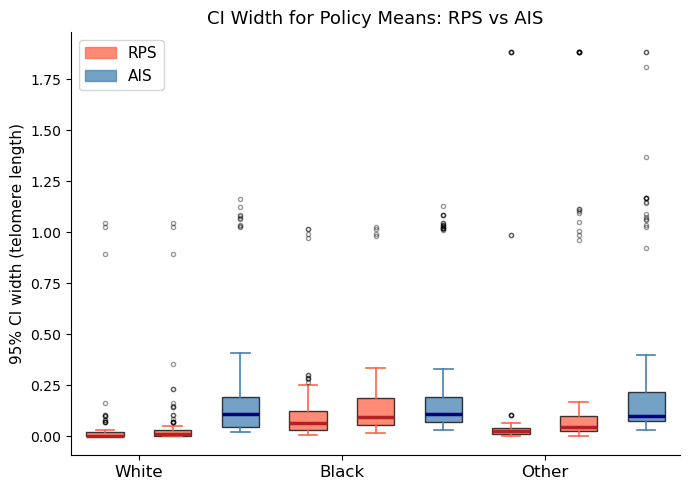

In [164]:
import matplotlib.patches as mpatches

def weighted_quantile(values, weights, quantiles):
    values = np.asarray(values, dtype=float)
    weights = np.asarray(weights, dtype=float)
    sorter = np.argsort(values)
    sorted_vals = values[sorter]
    sorted_w = weights[sorter]
    cumw = np.cumsum(sorted_w)
    cumw /= cumw[-1]
    return np.interp(quantiles, cumw, sorted_vals)

# --- RPS: normalize model posterior probabilities ---
w_rps = np.array(model_post_prob_2, dtype=float)
w_rps /= w_rps.sum()
beta_arr_rps = np.array(beta_models)       # (n_rps_models, 270)

# --- RPS3: normalize model posterior probabilities ---
w_rps3 = np.array(model_post_prob_3, dtype=float)
w_rps3 /= w_rps3.sum()
beta_arr_rps3 = np.array(beta_models3)       # (n_rps_models, 270)

# --- AIS: already-normalized weights ---
w_ais = np.array(ais_out.normw, dtype=float)
beta_arr_ais = np.array(beta_models_ais)   # (n_ais_samples, 270)

# --- Compute weighted 95% CIs for every policy ---
q_rps = np.zeros((270, 3))   # [q025, q50, q975]
q_rps3 = np.zeros((270, 3))   # [q025, q50, q975]
q_ais = np.zeros((270, 3))
for p in range(270):
    q_rps[p] = weighted_quantile(beta_arr_rps[:, p], w_rps, [0.025, 0.5, 0.975])
    q_rps3[p] = weighted_quantile(beta_arr_rps3[:, p], w_rps3, [0.025, 0.5, 0.975])
    q_ais[p] = weighted_quantile(beta_arr_ais[:, p], w_ais, [0.025, 0.5, 0.975])

# --- CI widths ---
width_rps = q_rps[:, 2] - q_rps[:, 0]   # (270,)
width_rps3 = q_rps3[:, 2] - q_rps3[:, 0]
width_ais = q_ais[:, 2] - q_ais[:, 0]

# --- Grouped boxplot: one pair per race ---
race_names = ["White", "Black", "Other"]
fig, ax = plt.subplots(figsize=(7, 5))

bp_kw_rps = dict(widths=0.55, patch_artist=True,
                 boxprops=dict(facecolor='tomato', alpha=0.75),
                 medianprops=dict(color='firebrick', lw=2.5),
                 whiskerprops=dict(color='tomato', lw=1.2),
                 capprops=dict(color='tomato', lw=1.2),
                 flierprops=dict(marker='o', color='tomato', alpha=0.4, markersize=3))
bp_kw_rps3 = dict(widths=0.55, patch_artist=True,
                 boxprops=dict(facecolor='tomato', alpha=0.75),
                 medianprops=dict(color='firebrick', lw=2.5),
                 whiskerprops=dict(color='tomato', lw=1.2),
                 capprops=dict(color='tomato', lw=1.2),
                 flierprops=dict(marker='o', color='tomato', alpha=0.4, markersize=3))
bp_kw_ais = dict(widths=0.55, patch_artist=True,
                 boxprops=dict(facecolor='steelblue', alpha=0.75),
                 medianprops=dict(color='navy', lw=2.5),
                 whiskerprops=dict(color='steelblue', lw=1.2),
                 capprops=dict(color='steelblue', lw=1.2),
                 flierprops=dict(marker='o', color='steelblue', alpha=0.4, markersize=3))

for race_idx in range(3):
    sl = slice(race_idx * 90, (race_idx + 1) * 90)
    pos_rps = race_idx * 3 + 1
    pos_rps3 = race_idx * 3 + 2
    pos_ais = race_idx * 3 + 3
    ax.boxplot(width_rps[sl], positions=[pos_rps], **bp_kw_rps)
    ax.boxplot(width_rps3[sl], positions=[pos_rps3], **bp_kw_rps3)
    ax.boxplot(width_ais[sl], positions=[pos_ais], **bp_kw_ais)

ax.set_xticks([1.5, 4.5, 7.5])
ax.set_xticklabels(race_names, fontsize=12)
ax.set_ylabel("95% CI width (telomere length)", fontsize=11)
ax.set_title("CI Width for Policy Means: RPS vs AIS", fontsize=13)
ax.spines[['top', 'right']].set_visible(False)

handles = [
    mpatches.Patch(color='tomato', alpha=0.75, label='RPS'),
    mpatches.Patch(color='steelblue', alpha=0.75, label='AIS'),
]
ax.legend(handles=handles, fontsize=11)

plt.tight_layout()
plt.savefig('../Figures/nhanes_new/ci_width_boxplot_rps_vs_ais3.png', dpi=300, bbox_inches='tight')
plt.show()

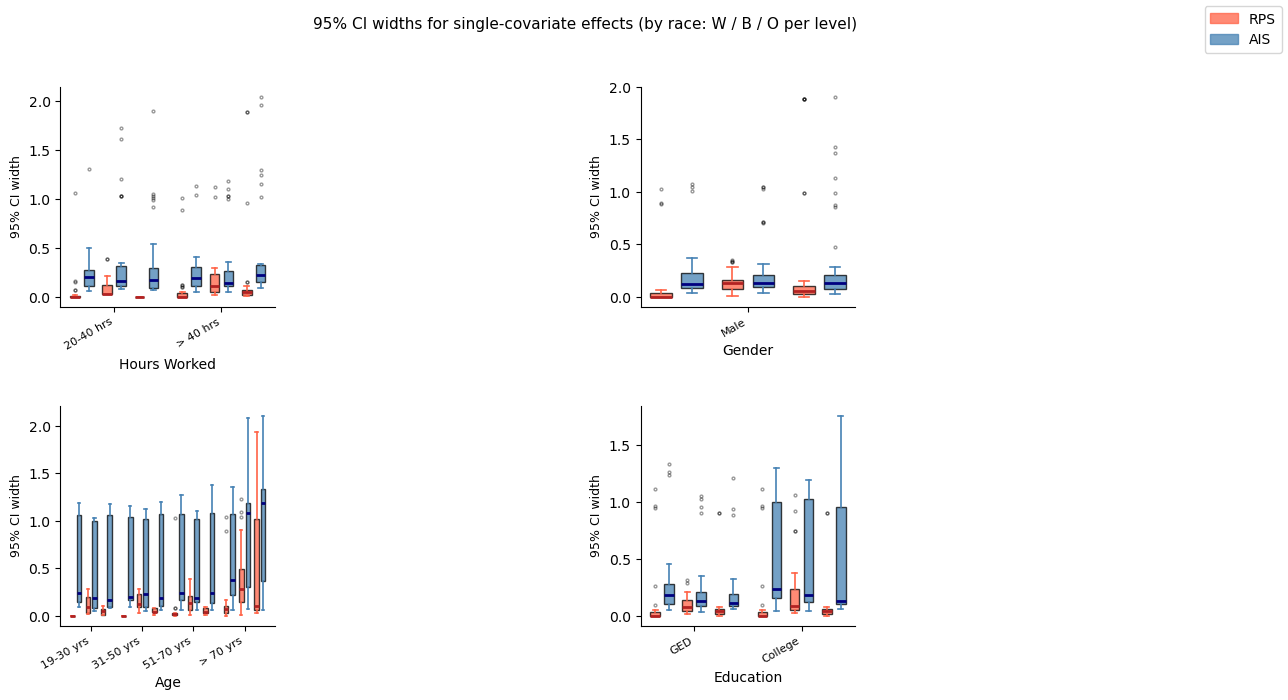

In [ ]:
# CI widths for single-covariate effects, mirroring the heatmap layout.
# For each covariate c and level v > 1:
#   effect = beta[p] - beta[control_p], where control_p is p with covariate c set to 1.
# Boxplots show the distribution of 95% CI widths across policies at that (race, level).

cov_labels   = ["Hours Worked", "Gender", "Age", "Education"]
levels_labels = [
    ["20-40 hrs", "> 40 hrs"],
    ["Male"],
    ["19-30 yrs", "31-50 yrs", "51-70 yrs", "> 70 yrs"],
    ["GED", "College"],
]
race_title = ["White", "Black", "Other"]

fig, axes = plt.subplots(2, 4, figsize=(14, 7),
                         gridspec_kw={"hspace": 0.45, "wspace": 0.35})

for covariate_idx in range(4):
    row = covariate_idx // 2
    col_base = (covariate_idx % 2) * 2   # two axes per covariate: one per layout column pair
    # use a single axis per covariate
    ax = axes[row, col_base]
    # hide the unused paired axis
    axes[row, col_base + 1].set_visible(False)

    num_levels = R[covariate_idx] - 2     # levels above baseline (v=2,3,...)
    level_vals = list(range(2, R[covariate_idx]))   # [2, 3, ...]

    # collect CI widths: widths_rps[race_idx][level_idx] = list of widths
    widths_rps = [[[] for _ in range(num_levels)] for _ in range(3)]
    widths_ais = [[[] for _ in range(num_levels)] for _ in range(3)]

    for p, pol in enumerate(all_policies_race):
        v = pol[covariate_idx]
        if v == 1:
            continue
        race_idx = int(pol[4]) - 1     # 0=White, 1=Black, 2=Other
        lv_idx   = int(v) - 2          # 0-indexed level above baseline

        control_key = list(pol)
        control_key[covariate_idx] = 1
        cp = all_policies_race_reverse[tuple(control_key)]

        eff_rps = beta_arr_rps[:, p] - beta_arr_rps[:, cp]
        q_rps   = weighted_quantile(eff_rps, w_rps, [0.025, 0.975])
        widths_rps[race_idx][lv_idx].append(q_rps[1] - q_rps[0])

        eff_ais = beta_arr_ais[:, p] - beta_arr_ais[:, cp]
        q_ais   = weighted_quantile(eff_ais, w_ais, [0.025, 0.975])
        widths_ais[race_idx][lv_idx].append(q_ais[1] - q_ais[0])

    # Build grouped positions: for each level, 3 race pairs (RPS, AIS) side by side
    gap_between_levels = 3 * 3 + 1    # 3 races * (rps+ais) + spacing
    positions_rps = []
    positions_ais = []
    data_rps = []
    data_ais = []
    tick_positions = []
    tick_labels = []

    base = 1
    for lv_idx in range(num_levels):
        level_center = []
        for race_idx in range(3):
            pos_r = base + race_idx * 3
            pos_a = pos_r + 1.3
            positions_rps.append(pos_r)
            positions_ais.append(pos_a)
            data_rps.append(widths_rps[race_idx][lv_idx])
            data_ais.append(widths_ais[race_idx][lv_idx])
            level_center.append((pos_r + pos_a) / 2)
        tick_positions.append(np.mean(level_center))
        tick_labels.append(levels_labels[covariate_idx][lv_idx])
        base += gap_between_levels

    bp_kw = dict(widths=0.9, patch_artist=True, manage_ticks=False)
    for i, (pos_r, pos_a, d_r, d_a) in enumerate(
            zip(positions_rps, positions_ais, data_rps, data_ais)):
        race_idx = i % 3
        color_r = ['tomato', 'tomato', 'tomato'][race_idx]
        color_a = ['steelblue', 'steelblue', 'steelblue'][race_idx]
        ax.boxplot(d_r, positions=[pos_r],
                   boxprops=dict(facecolor=color_r, alpha=0.75),
                   medianprops=dict(color='firebrick', lw=2),
                   whiskerprops=dict(color=color_r, lw=1.2),
                   capprops=dict(color=color_r, lw=1.2),
                   flierprops=dict(marker='o', color=color_r, alpha=0.4, markersize=2),
                   **bp_kw)
        ax.boxplot(d_a, positions=[pos_a],
                   boxprops=dict(facecolor=color_a, alpha=0.75),
                   medianprops=dict(color='navy', lw=2),
                   whiskerprops=dict(color=color_a, lw=1.2),
                   capprops=dict(color=color_a, lw=1.2),
                   flierprops=dict(marker='o', color=color_a, alpha=0.4, markersize=2),
                   **bp_kw)

    ax.set_xticks(tick_positions, tick_labels, fontsize=8, rotation=30, ha='right')
    ax.set_xlabel(cov_labels[covariate_idx], fontsize=10)
    ax.set_ylabel("95% CI width", fontsize=9)
    ax.spines[['top', 'right']].set_visible(False)

# Race legend (W/B/O not distinguished by color here; RPS vs AIS distinguished)
handles = [
    mpatches.Patch(color='tomato',    alpha=0.75, label='RPS'),
    mpatches.Patch(color='steelblue', alpha=0.75, label='AIS'),
]
fig.legend(handles=handles, loc='upper right', fontsize=10)
fig.suptitle("95% CI widths for single-covariate effects (by race: W / B / O per level)",
             fontsize=11)
plt.savefig('../Figures/nhanes_new/ci_width_effects_by_cov_level.png', dpi=300, bbox_inches='tight')
plt.show()